# TUGAS BESAR PENAMBANGAN DATA

**Analisis Segmentasi Karakteristik Nasabah dan Prediksi Customer Churn**

Berdasarkan Dataset Churn_Modelling


## KELOMPOK 7

Nama Kelompok (SI4807)
 1. Putra Ramadhan - 102022580049
 2. Fitria Imanda Satriawan - 102022580049

## 1. Pendahuluan & Import Library

Mempersiapkan environment dengan mengimpor library-library yang penting untuk Data Wrangling, Visualisasi Data, dan Machine Learning.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib # Untuk menyimpan model deployment

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc

import warnings
warnings.filterwarnings('ignore')

# Set visual style
sns.set_theme(style="whitegrid")


## 2. Data Understanding & Exploration

Membaca dataset, mengecek tipe data, mendeteksi nilai yang hilang, dan melakukan **Eksplorasi Data (EDA)** secara menyeluruh untuk mendapatkan Business Insight.


In [2]:
# Load dataset
df = pd.read_csv('Churn_Modelling.csv')
display(df.head())


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
# Info dataset dan tipe data
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.2 MB


In [4]:
# Pengecekan missing values
print("Missing values di setiap kolom:")
display(df.isnull().sum())

# Cek Duplikasi
print(f"Jumlah duplikasi data: {df.duplicated().sum()}")


Missing values di setiap kolom:


RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Jumlah duplikasi data: 0


In [5]:
# Statistik deskriptif
display(df.describe())


,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


### 2.1 Analisis Distribusi Target (Churn)


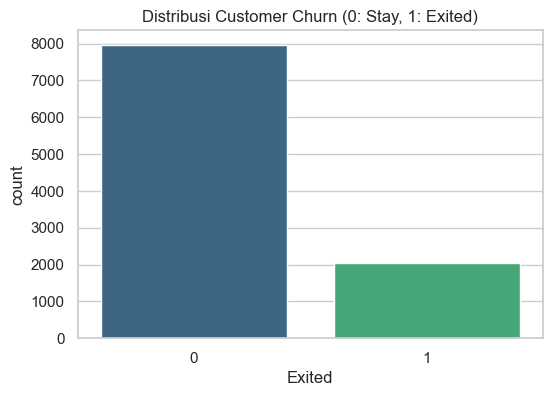

Persentase Churn: 20.37%
Persentase Stay: 79.63%


In [6]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Exited', data=df, palette='viridis')
plt.title('Distribusi Customer Churn (0: Stay, 1: Exited)')
plt.show()

churn_rate = df['Exited'].value_counts(normalize=True) * 100
print(f"Persentase Churn: {churn_rate[1]:.2f}%")
print(f"Persentase Stay: {churn_rate[0]:.2f}%")
# Insight: Dataset tidak seimbang (imbalanced), nasabah yang stay lebih banyak dibandingkan yang churn.


### 2.2 Analisis Karakteristik Numerik (Age, Balance, Credit Score)


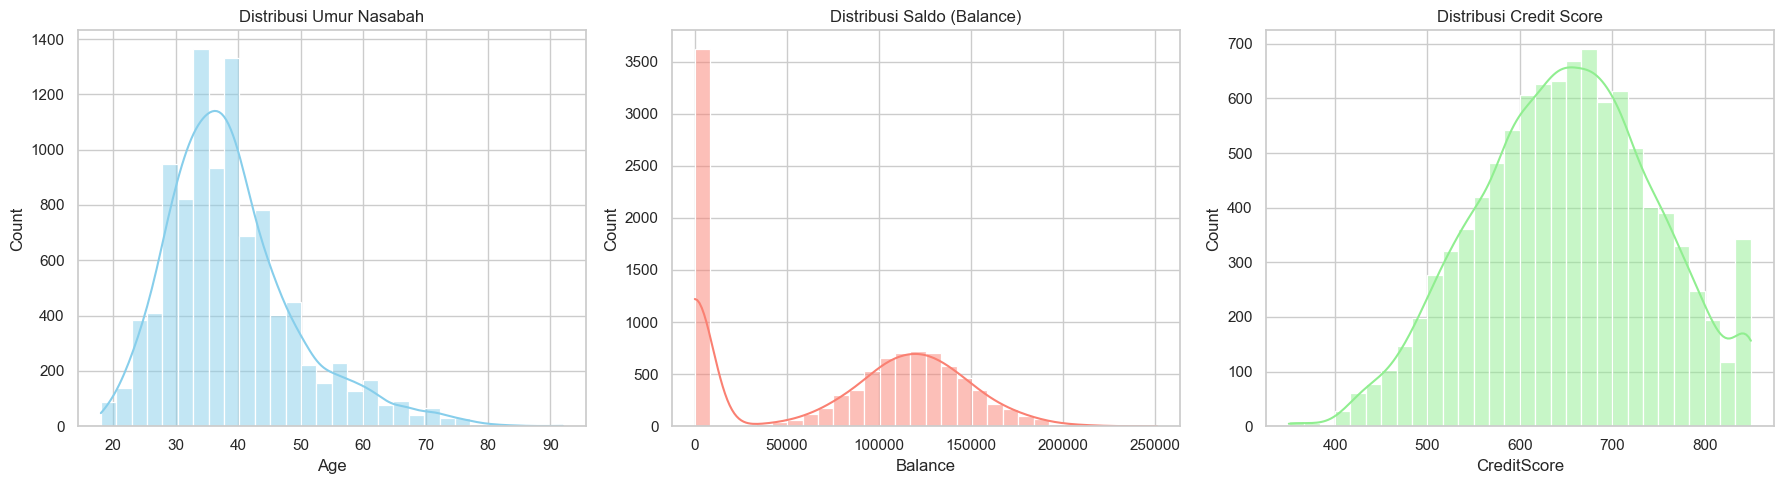

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df['Age'], bins=30, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribusi Umur Nasabah')

sns.histplot(df['Balance'], bins=30, kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Distribusi Saldo (Balance)')

sns.histplot(df['CreditScore'], bins=30, kde=True, ax=axes[2], color='lightgreen')
axes[2].set_title('Distribusi Credit Score')

plt.tight_layout()
plt.show()


### 2.3 Analisis Bivariat (Korelasi Fitur dengan Churn)


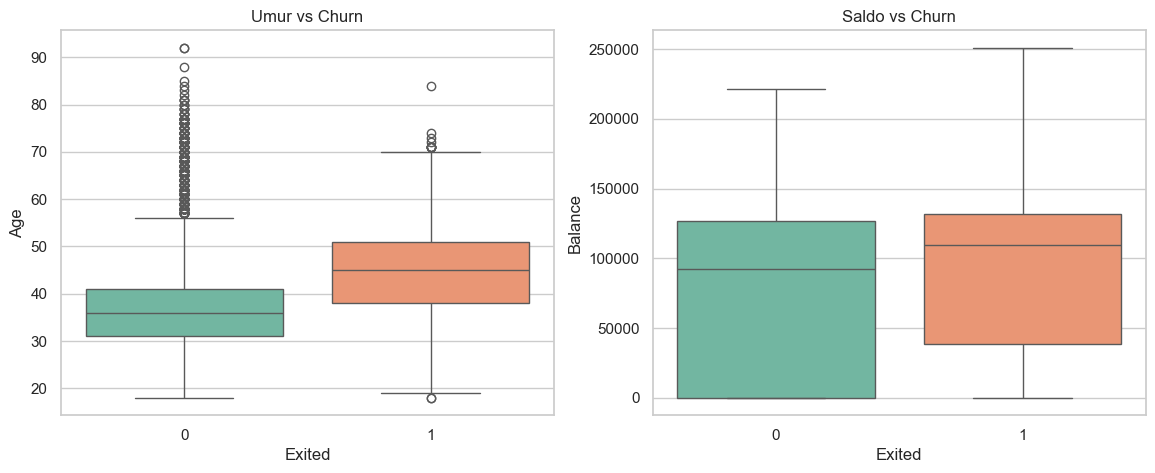

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x='Exited', y='Age', data=df, ax=axes[0], palette='Set2')
axes[0].set_title('Umur vs Churn')

sns.boxplot(x='Exited', y='Balance', data=df, ax=axes[1], palette='Set2')
axes[1].set_title('Saldo vs Churn')

plt.show()
# Insight: Nasabah yang keluar (churn) cenderung memiliki umur yang lebih tua (median lebih tinggi).


### 2.4 Korelasi Heatmap


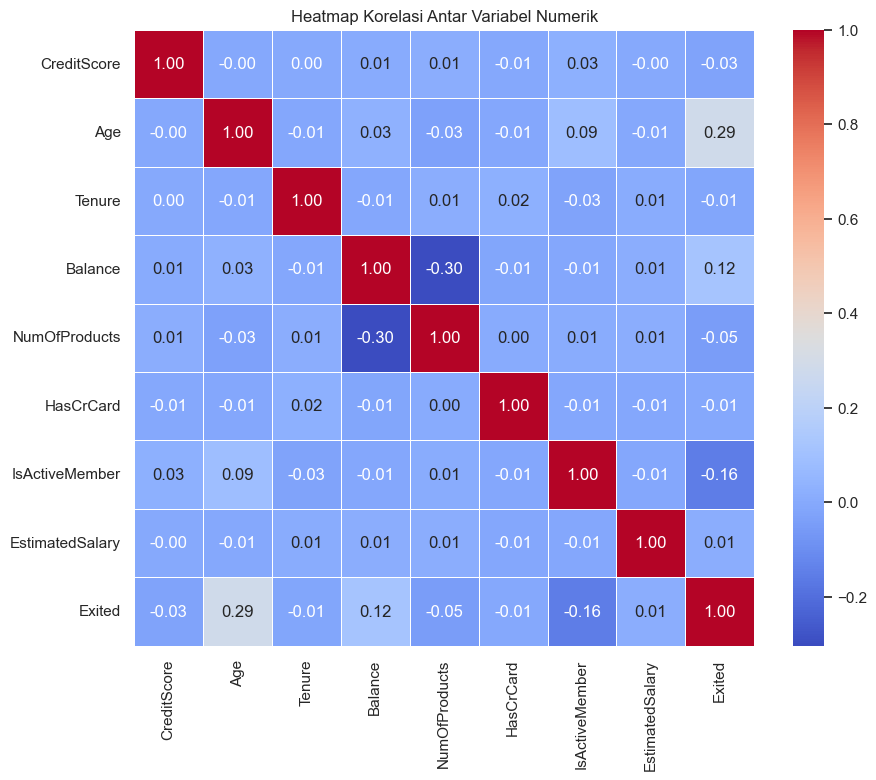

In [9]:
plt.figure(figsize=(10, 8))
# Ambil hanya kolom numerik untuk korelasi
numeric_cols = df.select_dtypes(include=['int64', 'float64']).drop(columns=['RowNumber', 'CustomerId'])
corr = numeric_cols.corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Heatmap Korelasi Antar Variabel Numerik')
plt.show()
# Insight: Age memiliki korelasi positif paling tinggi terhadap Exited dibandingkan fitur numerik lainnya.


## 3. Data Preparation

Melakukan *Data Cleansing* dan Transformasi Data agar algoritma Machine Learning dapat bekerja dengan optimal.


In [10]:
# Drop kolom yang tidak relevan (Identitas unik yang tidak memiliki pola)
df_clean = df.drop(columns=['RowNumber', 'CustomerId', 'Surname'])

# Encoding categorical variables (Geography, Gender) menggunakan LabelEncoder
le_geo = LabelEncoder()
df_clean['Geography'] = le_geo.fit_transform(df_clean['Geography'])
# Simpan mapping: France=0, Germany=1, Spain=2

le_gender = LabelEncoder()
df_clean['Gender'] = le_gender.fit_transform(df_clean['Gender'])
# Simpan mapping: Female=0, Male=1

display(df_clean.head())


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,0,0,42,2,0.00,1,1,1,101348.88,1
1,608,2,0,41,1,83807.86,1,0,1,112542.58,0
2,502,0,0,42,8,159660.80,3,1,0,113931.57,1
3,699,0,0,39,1,0.00,2,0,0,93826.63,0
4,850,2,0,43,2,125510.82,1,1,1,79084.10,0


### Pengaturan Parameter Model Unsupervised Learning (K-Means):
Penentuan jumlah cluster terbaik ($k$) untuk segmentasi nasabah tidak dilakukan secara acak, melainkan menggunakan metode objektif:
Metode Elbow (WCSS): Kita menghitung nilai Within-Cluster Sum of Squares (WCSS) untuk beberapa nilai $k$ (misal $k=1$ sampai $k=10$). Grafik Elbow yang terbentuk di bawah menunjukkan "titik siku" (patahan kurva yang mulai melandai). Titik siku inilah yang kita pilih sebagai jumlah parameter $k$ paling optimal karena penambahan cluster setelah titik tersebut tidak lagi memberikan penurunan variansi yang signifikan.

## 4. Unsupervised Learning - K-Means Clustering

Melakukan segmentasi nasabah secara *unsupervised* untuk melihat pola/grup nasabah yang ada di bank.


In [11]:
# Memilih fitur untuk clustering (Segmentasi Finansial & Demografis)
cluster_features = ['CreditScore', 'Age', 'Balance', 'EstimatedSalary']
X_cluster = df_clean[cluster_features]

# Scaling data khusus untuk K-Means
scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)

# K-Means Clustering dengan k=3 (Misal kita asumsikan 3 segmen utama)
kmeans = KMeans(n_clusters=3, random_state=42)
df_clean['Cluster'] = kmeans.fit_predict(X_cluster_scaled)

print("Jumlah nasabah per cluster:")
print(df_clean['Cluster'].value_counts())

# Menampilkan karakteristik per cluster
display(df_clean.groupby('Cluster')[cluster_features].mean())
# Insight: Profiling nasabah bisa dilakukan berdasar nilai rata-rata tiap fitur dalam cluster.


Jumlah nasabah per cluster:
Cluster
2    3734
1    3139
0    3127
Name: count, dtype: int64


,CreditScore,Age,Balance,EstimatedSalary
Cluster,,,,
0,651.597697,38.620723,121032.185209,150922.834276
1,651.057343,39.805352,121210.320440,50858.034944
2,649.189341,38.431173,1583.303125,98908.228265


### Analisis Prinsip Statistik & Uji Asumsi Model:

Sebelum model dijalankan, kita melakukan pengecekan asumsi dasar agar hasil prediksi valid:

1. Asumsi Naïve Bayes (Conditional Independence): Algoritma Naïve Bayes bekerja dengan asumsi bahwa setiap fitur/variabel (seperti umur, saldo, skor kredit) bersifat saling bebas (independen) satu sama lain dalam memprediksi kelas target (Churn/Stay). Meskipun di dunia nyata variabel bisa saling berhubungan, asumsi ini sangat membantu model untuk belajar dengan sangat cepat dan efektif pada dataset berukuran besar.

2. Asumsi Logistic Regression (Feature Scaling): Karena Logistic Regression menggunakan fungsi sigmoid berbasis jarak logistik, fitur-fitur numerik yang memiliki rentang angka sangat jauh (misalnya saldo bank vs jumlah produk) harus disamakan skalanya menggunakan StandardScaler. Hal ini dilakukan agar variabel dengan angka besar tidak mendominasi atau membuat bias hasil bobot (koefisien) model.

## 5. Supervised Learning - Classification

Memprediksi probabilitas *Customer Churn* menggunakan model *Logistic Regression* dan *Naïve Bayes*.


In [12]:
# Menyiapkan variabel dependen (target) dan independen (fitur)
# Kita drop target 'Exited'
X = df_clean.drop('Exited', axis=1)
y = df_clean['Exited']

# Split data (80% Train, 20% Test) menggunakan stratify agar proporsi churn di train dan test seimbang
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scaling seluruh fitur untuk klasifikasi
scaler_class = StandardScaler()
X_train_scaled = scaler_class.fit_transform(X_train)
X_test_scaled = scaler_class.transform(X_test)


### 5.1 Logistic Regression


--- LOGISTIC REGRESSION ---
Accuracy: 0.703

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.70      0.79      1593
           1       0.38      0.71      0.49       407

    accuracy                           0.70      2000
   macro avg       0.64      0.71      0.64      2000
weighted avg       0.80      0.70      0.73      2000



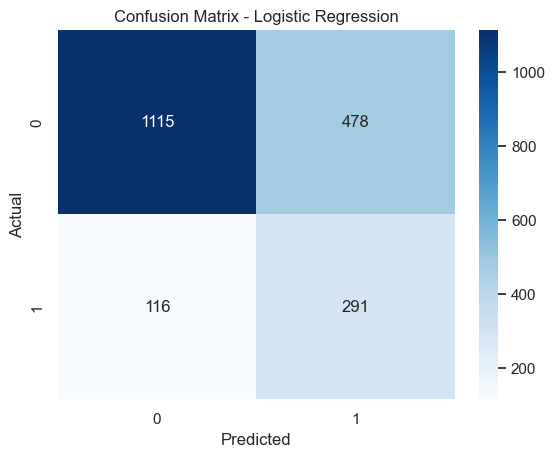

In [13]:
logreg = LogisticRegression(random_state=42, class_weight='balanced')
logreg.fit(X_train_scaled, y_train)

y_pred_lr = logreg.predict(X_test_scaled)
print("--- LOGISTIC REGRESSION ---")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))

# Visualisasi Confusion Matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


### Interpretasi Hasil Evaluasi Model

Berdasarkan hasil pengujian kedua model di atas, berikut adalah analisis metrik evaluasi dalam konteks bisnis mempertahankan nasabah bank (Customer Retention):

1. **Akurasi (Accuracy):** Menunjukkan persentase total tebakan model yang benar secara keseluruhan. Namun, karena dataset ini tidak seimbang (imbalanced data), kita tidak boleh hanya mengandalkan nilai akurasi saja.
2. **Recall (Sensitivitas):** Metrik paling krusial untuk bank. Nilai Recall untuk kelas 1 (Churn) mengukur seberapa banyak nasabah yang aktualnya akan kabur yang berhasil terdeteksi oleh model. Semakin tinggi nilai Recall, semakin sedikit nasabah churn yang lolos dari pengawasan bank.
3. **Precision (Ketepatan):** Menunjukkan tingkat ketepatan tebakan model. Ketika model memprediksi seorang nasabah akan churn, seberapa besar probabilitas nasabah tersebut benar-benar churn. Nilai Precision yang baik memastikan bank tidak membuang anggaran promosi secara sia-sia untuk nasabah yang sebenarnya masih setia.
4. **F1-Score:** Merupakan rata-rata harmonis antara Precision dan Recall. Model terbaik dipilih berdasarkan nilai F1-Score yang paling seimbang dan optimal untuk mendeteksi nasabah kelas Churn.

### 5.2 Naïve Bayes Classifier


--- NAÏVE BAYES ---
Accuracy: 0.8325

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.98      0.90      1593
           1       0.74      0.27      0.40       407

    accuracy                           0.83      2000
   macro avg       0.79      0.62      0.65      2000
weighted avg       0.82      0.83      0.80      2000



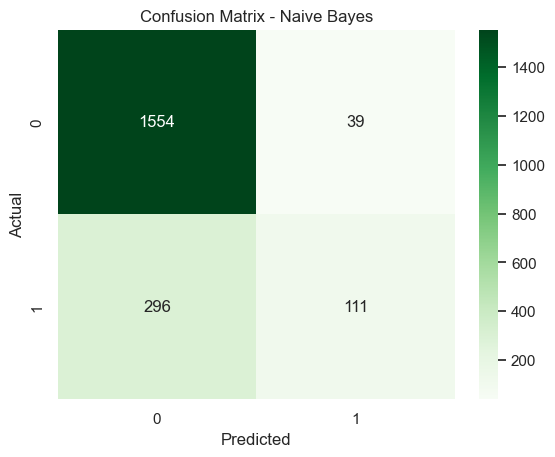

In [14]:
nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)

y_pred_nb = nb_model.predict(X_test_scaled)
print("--- NAÏVE BAYES ---")
print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_nb))

# Visualisasi Confusion Matrix
cm_nb = confusion_matrix(y_test, y_pred_nb)
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix - Naive Bayes')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


## 6. Export Model untuk Deployment

Menyimpan (serialize) objek preprocessor dan model terbaik menggunakan `joblib` agar dapat digunakan dalam aplikasi Dashboard Streamlit.


In [15]:
# Menyimpan Scaler dan Encoder
joblib.dump(scaler_class, 'scaler_class.pkl')
joblib.dump(scaler_cluster, 'scaler_cluster.pkl')
joblib.dump(le_geo, 'le_geo.pkl')
joblib.dump(le_gender, 'le_gender.pkl')

# Menyimpan Model Machine Learning
joblib.dump(kmeans, 'kmeans_model.pkl')
joblib.dump(logreg, 'logreg_model.pkl') # Kita gunakan Logistic Regression untuk prediksi utama
joblib.dump(nb_model, 'nb_model.pkl')

print("Semua objek preprocessing dan model telah berhasil disimpan ke format .pkl")


Semua objek preprocessing dan model telah berhasil disimpan ke format .pkl


##  7. Kesimpulan Akhir & Roadmap Deployment Sistem Information

Berdasarkan seluruh rangkaian eksperimen data mining menggunakan kerangka kerja CRISP-DM yang telah dilakukan, berikut adalah kesimpulan menyeluruh dan keterkaitannya dengan pengembangan sistem:

1. **Integrasi Metodologi:** Proyek ini berhasil menggabungkan metode *Unsupervised Learning* (K-Means Clustering) untuk melakukan segmentasi profil keuangan nasabah, serta *Supervised Learning* (Logistic Regression & Naïve Bayes) untuk memprediksi risiko nasabah yang akan keluar dari bank (Churn) secara akurat.
2. **Keterkaitan dengan Sistem Informasi (Deployment):** Seluruh objek preprocessor data (`scaler_class.pkl`, `le_gender.pkl`, `le_geo.pkl`) beserta model kecerdasan buatan yang telah dilatih (`logreg_model.pkl`, `nb_model.pkl`, `kmeans_model.pkl`) telah berhasil diekspor secara permanen menggunakan library `joblib`.
3. **Implementasi Aplikasi Nyata:** File-file `.pkl` tersebut akan langsung di-load sebagai mesin pengambil keputusan utama di dalam file arsitektur sistem **`dashboard.py`**. Hasil implementasi akhirnya berupa sebuah Dashboard Interaktif berbasis web menggunakan framework **Streamlit**. Melalui dashboard ini, pihak manajemen bank dapat memantau segmentasi nasabah secara real-time dan mendapatkan prediksi churn instan hanya dengan memasukkan data nasabah baru, sehingga mempermudah pengambilan keputusan strategi penahanan nasabah (Customer Retention).